# 第 6 节课 · Vision Transformer (ViT)

## 本 Notebook 目标

完成本 Notebook 后，你将能够：
1. 解释 ViT 如何把图像变成 patch 序列。
2. 理解 **CLS token** 和 **position embedding** 的作用。
3. 用 PyTorch 从头实现一个缩小版 ViT。
4. 在 CIFAR-10 上训练小 ViT，观察其表现。
5. 使用预训练 ViT（torchvision）在 CIFAR-10/100 上 fine-tune，体会"大数据预训练 + 下游微调"的威力。
6. 对比 CNN（ResNet）与 ViT 在数据量、归纳偏置、长程依赖上的差异。
7. 可视化 ViT 的 attention map，理解模型分类时在看哪里。

## 为什么要学 ViT？

Transformer 在 NLP 中取得了巨大成功。2021 年，Google 在论文 *An Image is Worth 16x16 Words* 中提出了 Vision Transformer，证明：

> **直接把标准 Transformer 应用到图像 patch 序列上，也能在图像分类任务中取得很好的效果。**

ViT 开启了计算机视觉的"Transformer 时代"：
- 图像分类：ViT、DeiT、Swin Transformer
- 目标检测：DETR、RT-DETR
- 语义分割：SegFormer、SAM
- 多模态：CLIP、LLaVA

下节课开始讲的目标检测和分割模型，很多都建立在 ViT 的基础上。

## 0. 环境准备

本节课需要 PyTorch 和 torchvision。需要安装的包（课上可统一安装）：
```bash
pip install torch torchvision numpy matplotlib
```

下面导入必要的库并检查版本。

In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体，确保图表标题能正常显示中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 自动选择计算设备
device = torch.device('cuda' if torch.cuda.is_available() else
                     'mps' if torch.backends.mps.is_available() else
                     'cpu')

print(f"PyTorch 版本: {torch.__version__}")
print(f"torchvision 版本: {models.__dict__.get('__version__', '内置') if hasattr(models, '__version__') else '内置'}")
print(f"使用设备: {device}")


PyTorch 版本: 2.12.1+cu130
torchvision 版本: 内置
使用设备: cuda


## 1. 从 CNN 到 ViT：为什么 Transformer 能做图像分类？

### CNN 的归纳偏置

CNN 有几个很强的"先验假设"：
- **局部性**：卷积核只关注局部区域。
- **平移等变性**：同一个卷积核滑过整幅图。
- **层次化特征**：浅层学边缘，深层学语义。

这些归纳偏置让 CNN 在中小数据集上表现很好。

### ViT 的想法

ViT 说：我们能不能去掉这些先验，直接让模型从数据中学习？

具体做法：
1. 把图像 $H \times W \times C$ 切成 $N$ 个 patch，每个 patch $P \times P$。
2. 把每个 patch 拉平并线性投影为 $D$ 维向量。
3. 把这些向量当成 NLP 中的 token 序列。
4. 输入标准 Transformer Encoder。
5. 加一个可学习的 **[CLS] token**，用它最后的输出做分类。

### 为什么能 work？

论文的关键发现是：
> 当预训练数据足够大（如 ImageNet-21k 或 JFT-300M）时，ViT 能超越 CNN；但在小数据上，CNN 的归纳偏置更有优势。

这告诉我们：**Transformer 需要更多数据来弥补缺失的归纳偏置。**

## 2. Patch Embedding：把图像切成"词"

论文中的公式（Eq. 1）：
$$\mathbf{x} \in \mathbb{R}^{H \times W \times C} \Rightarrow \mathbf{x}_p \in \mathbb{R}^{N \times (P^2 \cdot C)}$$

其中：
- $H, W$：图像高和宽
- $C$：通道数（RGB 为 3）
- $P$：patch 大小
- $N = HW / P^2$：patch 数量，也是序列长度

每个 patch 被拉平后，通过一个可学习的线性投影映射到 $D$ 维：
$$\mathbf{z}_0 = [\mathbf{x}_{\text{class}}; \mathbf{x}_p^1 \mathbf{E}; \mathbf{x}_p^2 \mathbf{E}; \cdots; \mathbf{x}_p^N \mathbf{E}] + \mathbf{E}_{\text{pos}}$$

### 实现技巧

可以用 `nn.Conv2d` 实现 patch embedding：
- `kernel_size = P`
- `stride = P`
- 输出通道数 = $D$

这样一张图 $(B, C, H, W)$ 经过卷积后变成 $(B, D, H/P, W/P)$，再展平为 $(B, N, D)$。

下面我们可视化 CIFAR-10 图片被切成 patch 的过程。

c:\Users\nan\miniconda3\envs\pytorch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


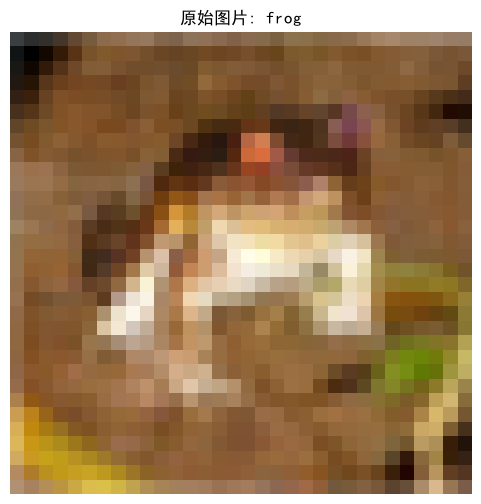

Patches shape: torch.Size([1, 48, 64])
每个 patch 维度: 48
Patch 数量: 64


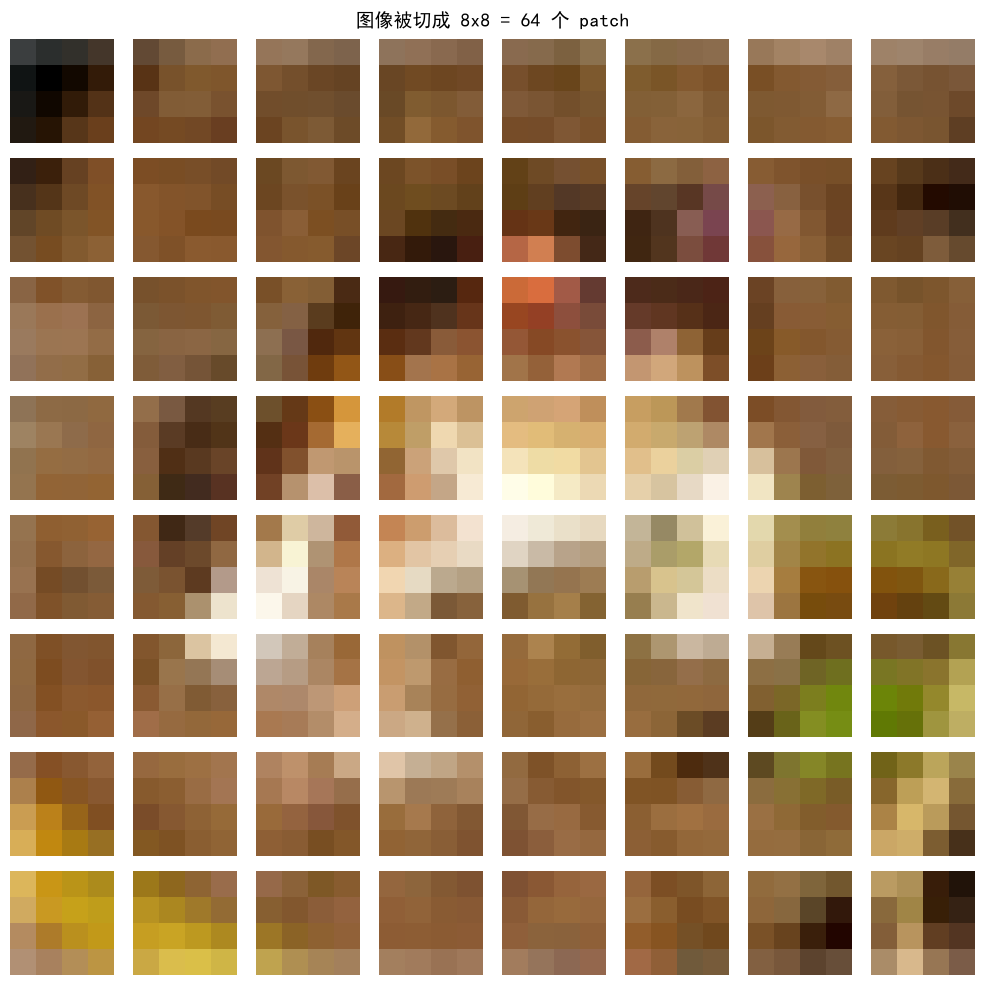

In [2]:
# 加载一张 CIFAR-10 图片用于可视化
from torchvision import datasets

# 临时加载训练集的第一张图（不需要做复杂变换）
temp_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
img, label = temp_dataset[0]  # img: (3, 32, 32)

# CIFAR-10 类别名
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 可视化原始图片
plt.figure(figsize=(6, 6))
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title(f"原始图片: {classes[label]}")
plt.axis('off')
plt.show()

# 把图片切成 patch
patch_size = 4  # CIFAR-10 是 32x32，用 4x4 patch 可以得到 8x8=64 个 patch
B, C, H, W = 1, 3, 32, 32
img_batch = img.unsqueeze(0)  # (1, 3, 32, 32)

# 用 unfold 提取 patch
# unfold(dimension, size, step) 会在指定维度上滑动窗口
patches = F.unfold(img_batch, kernel_size=patch_size, stride=patch_size)
# patches shape: (1, C*P*P, N) = (1, 48, 64)
print(f"Patches shape: {patches.shape}")
print(f"每个 patch 维度: {patches.shape[1]}")
print(f"Patch 数量: {patches.shape[2]}")

# 把 patches reshape 成 (N, C, P, P) 用于可视化
patches_vis = patches.view(1, C, patch_size, patch_size, -1)
patches_vis = patches_vis.permute(0, 4, 1, 2, 3).squeeze(0)  # (N, C, P, P)

# 画出所有 patch（8x8 网格）
num_patches_per_row = H // patch_size
fig, axes = plt.subplots(num_patches_per_row, num_patches_per_row, figsize=(10, 10))
for i in range(num_patches_per_row):
    for j in range(num_patches_per_row):
        idx = i * num_patches_per_row + j
        axes[i, j].imshow(patches_vis[idx].permute(1, 2, 0).numpy())
        axes[i, j].axis('off')
plt.suptitle(f"图像被切成 {num_patches_per_row}x{num_patches_per_row} = {patches_vis.shape[0]} 个 patch", fontsize=14)
plt.tight_layout()
plt.show()


> **观察**：
> 1. 原始图片被切成了 8x8=64 个 4x4 的小块。
> 2. 每个小块保留了局部视觉信息（边缘、颜色、纹理）。
> 3. ViT 会把这些小块按顺序排成一个序列，输入 Transformer。

## 3. CLS Token 与 Position Embedding

### CLS Token

ViT 借鉴了 BERT 的做法：在 patch 序列最前面加一个可学习的 **[CLS] token**。

为什么用它做分类？
- 它不参与任何具体 patch 的表示。
- 通过 self-attention，它可以"看"到所有 patch。
- 最后把 CLS token 的输出接一个分类头，输出类别概率。

> 论文也尝试了用所有 patch 输出的全局平均池化做分类，结果差不多，但 CLS token 更符合 NLP 的习惯。

### Position Embedding

Transformer 本身对输入顺序不敏感，所以需要给每个 patch 加上位置信息。

ViT 使用的是**可学习的一维位置编码**（1D learnable position embeddings）：
- 长度为 $N+1$（N 个 patch + 1 个 CLS token）。
- 每个位置是一个 $D$ 维向量，随机初始化，与模型一起训练。

> 论文附录中提到，他们也尝试了 2D 位置编码和相对位置编码，但效果差不多，因此使用最简单的 1D 可学习编码。

### Fine-tune 时分辨率变化

预训练时可能用 224x224 图像（patch=16，序列长度 196）。
Fine-tune 时如果用 384x384，序列长度会变成 576。

这时需要对预训练的位置编码做**二维插值**，把 14x14 的 grid 插值到 24x24 的 grid。这是 ViT 唯一需要手动注入 2D 先验的地方。

输入 shape: torch.Size([2, 3, 32, 32])
输出 tokens shape: torch.Size([2, 64, 192])
patch 数量: 64
每个 token 维度: 192

CLS token shape: torch.Size([1, 1, 192])
Position embedding shape: torch.Size([1, 65, 192])


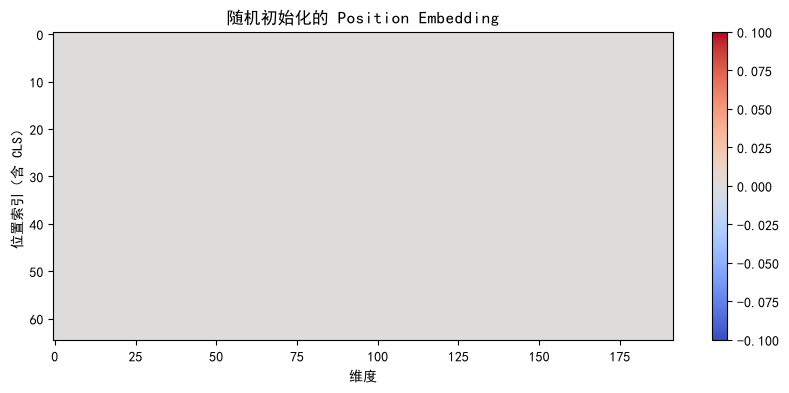

In [3]:
# 用 Conv2d 实现 Patch Embedding
class PatchEmbedding(nn.Module):
    """
    把图像切成 patch 并线性投影为 token。
    
    参数:
        img_size: 图像尺寸（假设高宽相等）
        patch_size: patch 大小
        in_channels: 输入通道数
        embed_dim: 投影后的维度 D
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # 用 Conv2d 实现 patch embedding
        # kernel_size=patch_size, stride=patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        """
        参数:
            x: (batch, channels, img_size, img_size)
        返回:
            tokens: (batch, num_patches, embed_dim)
        """
        # (B, C, H, W) -> (B, embed_dim, H/P, W/P)
        x = self.proj(x)
        
        # (B, embed_dim, H/P, W/P) -> (B, embed_dim, num_patches)
        x = x.flatten(2)
        
        # (B, embed_dim, num_patches) -> (B, num_patches, embed_dim)
        x = x.transpose(1, 2)
        
        return x


# 测试 Patch Embedding
patch_embed = PatchEmbedding(img_size=32, patch_size=4, embed_dim=192)
x = torch.randn(2, 3, 32, 32)
tokens = patch_embed(x)
print(f"输入 shape: {x.shape}")
print(f"输出 tokens shape: {tokens.shape}")
print(f"patch 数量: {patch_embed.num_patches}")
print(f"每个 token 维度: {tokens.shape[-1]}")

# 可视化 CLS token 和 position embedding 的初始化
num_patches = patch_embed.num_patches
embed_dim = 192

# CLS token: (1, 1, embed_dim)
cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
# Position embedding: (1, num_patches + 1, embed_dim)
pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

print(f"\nCLS token shape: {cls_token.shape}")
print(f"Position embedding shape: {pos_embed.shape}")

# 画出 position embedding 的初始化值
plt.figure(figsize=(10, 4))
plt.imshow(pos_embed[0].detach().numpy(), aspect='auto', cmap='coolwarm')
plt.xlabel('维度')
plt.ylabel('位置索引（含 CLS）')
plt.title('随机初始化的 Position Embedding')
plt.colorbar()
plt.show()


## 4. ViT Block：Pre-Norm + Multi-Head Attention + MLP

ViT 的 Transformer Encoder Block 和原始 Transformer 略有不同：
- 使用 **Pre-LayerNorm**（子层之前做 LayerNorm），而不是原始 Transformer 的 Post-LayerNorm。
- MLP 使用 **GELU** 激活函数，而不是 ReLU。

论文中的公式：
$$\mathbf{z}'_\ell = \text{MSA}(\text{LN}(\mathbf{z}_{\ell-1})) + \mathbf{z}_{\ell-1}$$
$$\mathbf{z}_\ell = \text{MLP}(\text{LN}(\mathbf{z}'_\ell)) + \mathbf{z}'_\ell$$

### MLP 结构

两层 Linear + GELU + Dropout：
$$\text{MLP}(x) = \text{Dropout}(\text{Linear}_2(\text{GELU}(\text{Linear}_1(x))))$$

输入输出维度都是 $D$，中间维度通常是 $4D$。

In [4]:
class ViTBlock(nn.Module):
    """
    Vision Transformer 的一个 Encoder Block（Pre-LN）。
    
    参数:
        embed_dim: token 维度 D
        num_heads: 注意力头数
        mlp_ratio: MLP 中间层维度 = embed_dim * mlp_ratio
        dropout: dropout 概率
    """
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        # Pre-LN：先 LayerNorm，再 Multi-Head Self-Attention
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        
        # Pre-LN：先 LayerNorm，再 MLP
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        """
        参数:
            x: (batch, num_tokens, embed_dim)
        返回:
            x: (batch, num_tokens, embed_dim)
            attn: (batch, num_heads, num_tokens, num_tokens)
        """
        # Multi-Head Self-Attention + 残差
        attn_out, attn = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out
        
        # MLP + 残差
        x = x + self.mlp(self.norm2(x))
        
        return x, attn


# 测试 ViT Block
vit_block = ViTBlock(embed_dim=192, num_heads=4)
x = torch.randn(2, 65, 192)  # 64 patches + 1 CLS
out, attn = vit_block(x)
print(f"输入 shape: {x.shape}")
print(f"输出 shape: {out.shape}")
print(f"Attention shape: {attn.shape}")


输入 shape: torch.Size([2, 65, 192])
输出 shape: torch.Size([2, 65, 192])
Attention shape: torch.Size([2, 65, 65])


## 5. 完整 ViT 实现

把 Patch Embedding、CLS Token、Position Embedding、ViT Blocks 和分类头组合起来。

### 模型变体

论文中定义的模型（Table 1）：

| 模型 | Layers | Hidden D | MLP size | Heads | Params |
|------|--------|----------|----------|-------|--------|
| ViT-Base | 12 | 768 | 3072 | 12 | 86M |
| ViT-Large | 24 | 1024 | 4096 | 16 | 307M |
| ViT-Huge | 32 | 1280 | 5120 | 16 | 632M |

### 课堂版本

由于 CIFAR-10 图片只有 32x32，我们用更小的配置：
- patch_size = 4
- embed_dim = 192
- depth = 6
- num_heads = 4
- mlp_ratio = 4

这样参数量约 2M，单 GPU 可训练。

In [5]:
class VisionTransformer(nn.Module):
    """
    完整的 Vision Transformer 分类模型。
    
    参数:
        img_size: 图像尺寸
        patch_size: patch 大小
        in_channels: 输入通道数
        num_classes: 分类类别数
        embed_dim: token 维度
        depth: Encoder Block 数量
        num_heads: 注意力头数
        mlp_ratio: MLP 隐藏层比例
        dropout: dropout 概率
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=192, depth=6, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        # CLS token: 一个可学习的向量
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Position embedding: (num_patches + 1, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_dropout = nn.Dropout(dropout)
        
        # Transformer Encoder Blocks
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        # 最后的 LayerNorm
        self.norm = nn.LayerNorm(embed_dim)
        
        # 分类头
        self.head = nn.Linear(embed_dim, num_classes)
        
        # 初始化
        self._init_weights()
    
    def _init_weights(self):
        """初始化权重"""
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        参数:
            x: (batch, channels, img_size, img_size)
        返回:
            logits: (batch, num_classes)
            all_attns: list of attention weights
        """
        B = x.size(0)
        
        # 1. Patch Embedding: (B, N, D)
        x = self.patch_embed(x)
        
        # 2. 拼上 CLS token: (B, 1, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, N+1, D)
        
        # 3. 加位置编码
        x = x + self.pos_embed
        x = self.pos_dropout(x)
        
        # 4. 通过 Transformer Blocks
        all_attns = []
        for block in self.blocks:
            x, attn = block(x)
            all_attns.append(attn)
        
        # 5. 最后的 LayerNorm
        x = self.norm(x)
        
        # 6. 取 CLS token 的输出做分类
        cls_output = x[:, 0]  # (B, D)
        logits = self.head(cls_output)
        
        return logits, all_attns


# 测试完整 ViT
small_vit = VisionTransformer(
    img_size=32, patch_size=4, num_classes=10,
    embed_dim=192, depth=6, num_heads=4, mlp_ratio=4.0
)
x = torch.randn(2, 3, 32, 32)
logits, attns = small_vit(x)
print(f"输入 shape: {x.shape}")
print(f"输出 logits shape: {logits.shape}")
print(f"Block 数量: {len(attns)}")
print(f"模型参数量: {sum(p.numel() for p in small_vit.parameters()) / 1e6:.2f}M")


输入 shape: torch.Size([2, 3, 32, 32])
输出 logits shape: torch.Size([2, 10])
Block 数量: 6
模型参数量: 2.69M


## 6. 加载 CIFAR-10 数据集

CIFAR-10 包含 50,000 张训练图片和 10,000 张测试图片，尺寸 32x32，共 10 类。

对于 ViT：
- 不需要复杂的预处理。
- 只做归一化。
- 数据增强可选（RandomCrop + RandomHorizontalFlip）。

> 注意：预训练 ViT 通常用 224x224 或 384x384，但 CIFAR-10 是 32x32。我们课堂上会分别训练"从头开始的小 ViT"和"加载 ImageNet 预训练权重后 fine-tune 的标准 ViT"。

In [6]:
# 数据预处理
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # 随机裁剪，增加数据多样性
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 均值方差
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 下载并加载数据集
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"类别数: {len(train_dataset.classes)}")


训练集大小: 50000
测试集大小: 10000
类别数: 10


## 7. 从头训练小 ViT on CIFAR-10

我们用课堂上设计的小 ViT 在 CIFAR-10 上训练。

训练配置：
- Epochs: 15
- Optimizer: AdamW（ViT 论文使用 Adam 配合较大 weight decay，AdamW 更常用）
- Learning rate: 1e-3 with cosine annealing
- Weight decay: 0.05

> 这个实验会让你直观感受：在小数据上，ViT 从头训练的效果可能不如 ResNet，因为缺少 CNN 的归纳偏置。


In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    """训练一个 epoch。兼容返回 tuple 的自定义模型和直接返回 logits 的标准模型。"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        output = model(images)
        # 处理自定义 ViT 返回 (logits, all_attns) 的情况
        logits = output[0] if isinstance(output, tuple) else output
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """评估模型。兼容返回 tuple 的自定义模型和直接返回 logits 的标准模型。"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            logits = output[0] if isinstance(output, tuple) else output
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total


# 创建小 ViT 模型
small_vit = VisionTransformer(
    img_size=32, patch_size=4, num_classes=10,
    embed_dim=192, depth=6, num_heads=4, mlp_ratio=4.0
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(small_vit.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

print("开始训练小 ViT（从头开始）...")
num_epochs = 15
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(small_vit, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(small_vit, test_loader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

print(f"\n最终测试准确率: {test_accs[-1]:.2f}%")


开始训练小 ViT（从头开始）...
Epoch [1/15] Train Loss: 1.9307, Train Acc: 28.01% | Test Loss: 1.6822, Test Acc: 37.40%
Epoch [5/15] Train Loss: 1.3253, Train Acc: 51.69% | Test Loss: 1.2663, Test Acc: 53.97%
Epoch [10/15] Train Loss: 1.0763, Train Acc: 61.08% | Test Loss: 1.0179, Test Acc: 63.15%
Epoch [15/15] Train Loss: 0.9127, Train Acc: 67.15% | Test Loss: 0.9147, Test Acc: 67.04%

最终测试准确率: 67.04%


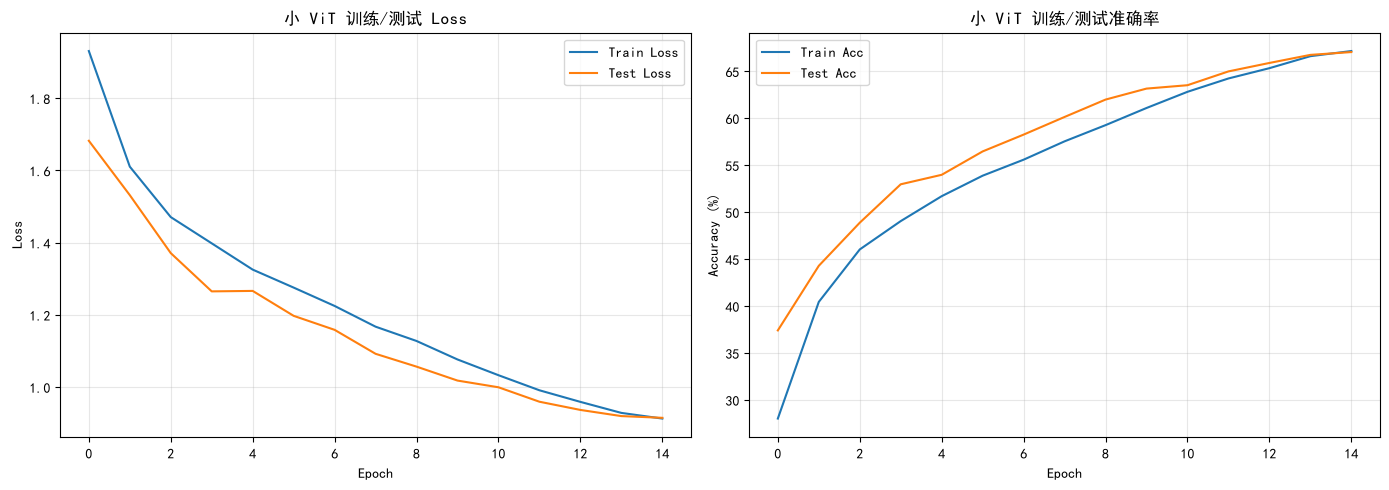

In [8]:
# 画出训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('小 ViT 训练/测试 Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(test_accs, label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('小 ViT 训练/测试准确率')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. 加载预训练 ViT 并在 CIFAR-10/100 上 Fine-tune

这是 ViT 论文的核心结论之一：
> **在大规模数据上预训练后，ViT 可以很好地迁移到下游任务。**

### 为什么预训练很重要？

- ViT 没有 CNN 的局部性和平移等变性等归纳偏置。
- 它需要从大量数据中"学会"图像的基本结构（边缘、纹理、形状）。
- 一旦学会了，这些特征可以迁移到各种下游任务。

### 实际操作

我们用 `torchvision.models.vit_b_16`（在 ImageNet-1K 上预训练）加载权重，然后：
1. 把输入分辨率从 224 改为 CIFAR-10 的 32（需要对 position embedding 插值）。
2. 把分类头从 1000 类改为 10 类。
3. 用较小的学习率 fine-tune。

> 注意：32x32 图片对 vit_b_16 来说非常小（patch=16 只能得到 2x2=4 个 patch），效果可能不好。因此我们通常会把 CIFAR-10 图片 resize 到 224x224，或者用更大的输入。

下面我们先在 CIFAR-10 上试试 resize 到 224 的效果。

In [9]:
# 加载预训练 ViT
pretrained_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# 查看模型结构
print(pretrained_vit)
print(f"\n原始分类头: {pretrained_vit.heads}")

# 修改分类头为 10 类
num_features = pretrained_vit.heads.head.in_features
pretrained_vit.heads = nn.Linear(num_features, 10)
pretrained_vit = pretrained_vit.to(device)

print(f"修改后分类头: {pretrained_vit.heads}")


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [10]:
# 为预训练 ViT 准备数据（resize 到 224x224）
transform_pretrained = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 统计
])

train_dataset_pretrained = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_pretrained)
test_dataset_pretrained = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_pretrained)

train_loader_pretrained = DataLoader(train_dataset_pretrained, batch_size=64, shuffle=True, num_workers=0)
test_loader_pretrained = DataLoader(test_dataset_pretrained, batch_size=64, shuffle=False, num_workers=0)

# 只训练分类头：冻结 backbone 所有参数，只解冻并训练新的分类头
for param in pretrained_vit.parameters():
    param.requires_grad = False
pretrained_vit.heads.requires_grad_(True)

# 优化器只传入 classification head 的参数
optimizer_pretrained = torch.optim.AdamW(pretrained_vit.heads.parameters(), lr=1e-3, weight_decay=0.05)
scheduler_pretrained = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pretrained, T_max=5)

print("Fine-tune 预训练 ViT on CIFAR-10（只训练分类头）...")
num_epochs_pretrained = 5
for epoch in range(num_epochs_pretrained):
    train_loss, train_acc = train_epoch(pretrained_vit, train_loader_pretrained, optimizer_pretrained, criterion, device)
    test_loss, test_acc = evaluate(pretrained_vit, test_loader_pretrained, criterion, device)
    scheduler_pretrained.step()
    
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_pretrained}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

print(f"\n预训练 ViT 最终测试准确率: {test_acc:.2f}%")


Fine-tune 预训练 ViT on CIFAR-10（只训练分类头）...
Epoch [1/5] Train Loss: 0.2325, Train Acc: 93.30% | Test Loss: 0.1608, Test Acc: 94.69%
Epoch [2/5] Train Loss: 0.1394, Train Acc: 95.50% | Test Loss: 0.1473, Test Acc: 95.36%
Epoch [4/5] Train Loss: 0.1119, Train Acc: 96.42% | Test Loss: 0.1392, Test Acc: 95.39%

预训练 ViT 最终测试准确率: 95.47%


> **预期观察**：
> 1. 从头训练的小 ViT 在 CIFAR-10 上可能达到 60-75% 左右的准确率（取决于训练轮数和随机种子）。
> 2. 预训练 ViT 即使只 fine-tune 10 个 epoch，也能达到 90%+ 的准确率。
> 3. 这验证了 ViT 论文的核心观点：**大数据预训练 + 下游微调是 ViT 发挥作用的关键。**

## 9. ResNet vs ViT：归纳偏置 vs 数据规模

为了更严谨地对比 CNN 和 Transformer，我们训练一个参数量相近的 ResNet-18，在相同条件下对比。

### 对比维度

| 维度 | ResNet-18 | 小 ViT |
|------|-----------|--------|
| 归纳偏置 | 强（局部性、平移等变） | 弱（只有 patch 划分） |
| 长程依赖 | 逐层扩大感受野 | 任意两层直接交互 |
| 数据效率 | 高（中小数据好） | 低（需要大数据预训练） |
| 参数量 | ~11M | ~2M |

> 注意：这里 ResNet-18 参数更多，主要是为了展示"在 CIFAR-10 这种小数据上，CNN 的归纳偏置很有用"。

In [11]:
# 加载 ResNet-18（从头训练）
resnet18 = models.resnet18(weights=None, num_classes=10).to(device)

optimizer_resnet = torch.optim.AdamW(resnet18.parameters(), lr=1e-3, weight_decay=0.05)
scheduler_resnet = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=10)

print("训练 ResNet-18（从头开始）...")
resnet_train_losses, resnet_test_losses = [], []
resnet_train_accs, resnet_test_accs = [], []

for epoch in range(10):
    train_loss, train_acc = train_epoch(resnet18, train_loader, optimizer_resnet, criterion, device)
    test_loss, test_acc = evaluate(resnet18, test_loader, criterion, device)
    scheduler_resnet.step()
    
    resnet_train_losses.append(train_loss)
    resnet_test_losses.append(test_loss)
    resnet_train_accs.append(train_acc)
    resnet_test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/10] "
              f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print(f"\nResNet-18 最终测试准确率: {resnet_test_accs[-1]:.2f}%")
print(f"小 ViT 最终测试准确率: {test_accs[-1]:.2f}%")


训练 ResNet-18（从头开始）...
Epoch [1/10] Train Acc: 43.69% | Test Acc: 55.91%
Epoch [5/10] Train Acc: 71.46% | Test Acc: 71.50%
Epoch [10/10] Train Acc: 81.82% | Test Acc: 80.76%

ResNet-18 最终测试准确率: 80.76%
小 ViT 最终测试准确率: 67.04%


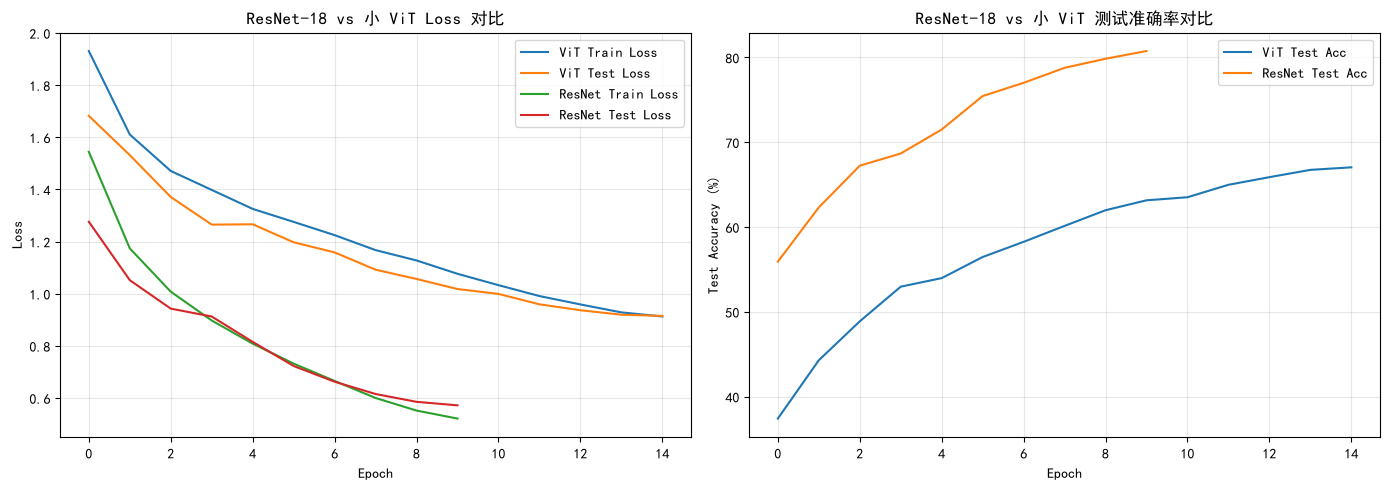

In [12]:
# 画出 ResNet vs ViT 对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='ViT Train Loss')
axes[0].plot(test_losses, label='ViT Test Loss')
axes[0].plot(resnet_train_losses, label='ResNet Train Loss')
axes[0].plot(resnet_test_losses, label='ResNet Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet-18 vs 小 ViT Loss 对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accs, label='ViT Test Acc')
axes[1].plot(resnet_test_accs, label='ResNet Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('ResNet-18 vs 小 ViT 测试准确率对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. 可视化 ViT 的 Attention

ViT 的一个优势是可解释性强：我们可以直接看模型在分类时关注了图像的哪些区域。

### 方法：CLS-to-patch Attention

取最后一层或中间某层的 attention weights，形状为 `(batch, num_heads, num_tokens, num_tokens)`。

我们关注 **CLS token（位置 0）对所有 patch（位置 1~N）的注意力**：
- 取出 `attn[:, :, 0, 1:]`，形状 `(batch, num_heads, N)`。
- 对所有 head 取平均。
- reshape 回图像网格（如 8x8）。
- 上采样到原图大小，叠加在原图上。

这样就能看到模型分类时"看哪里"。

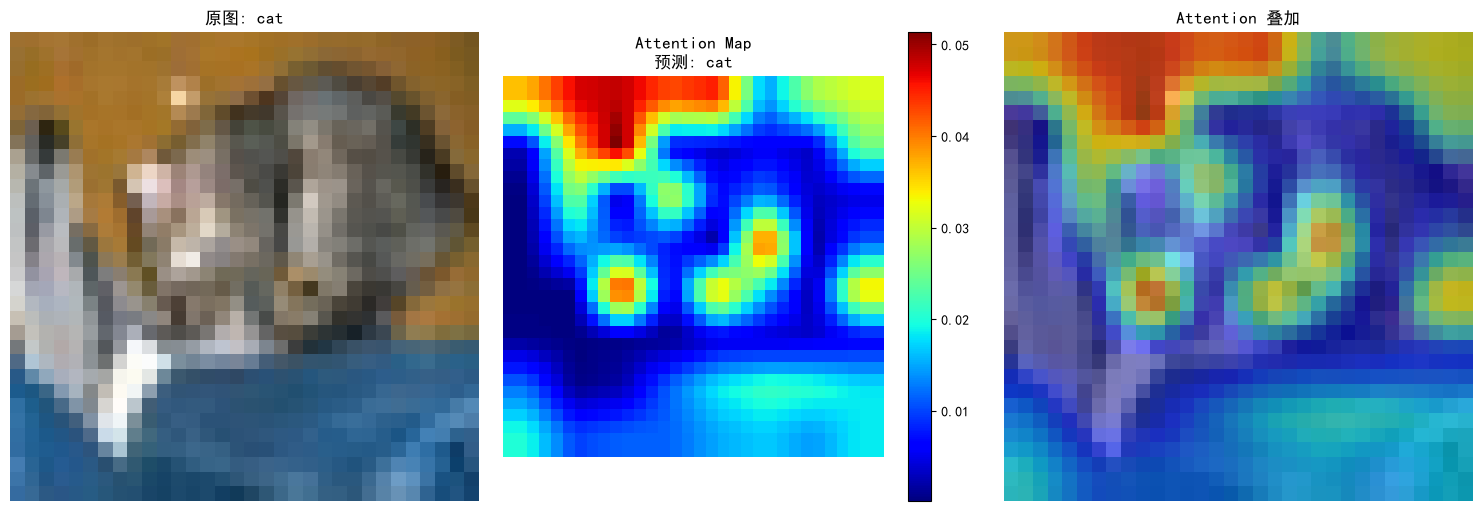

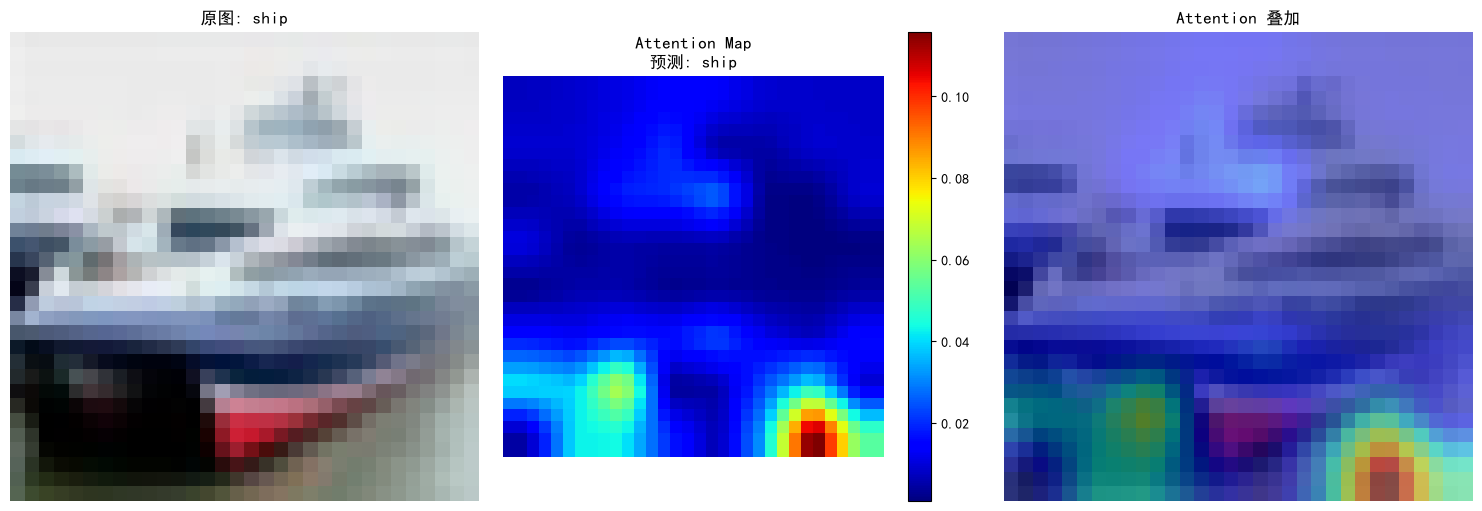

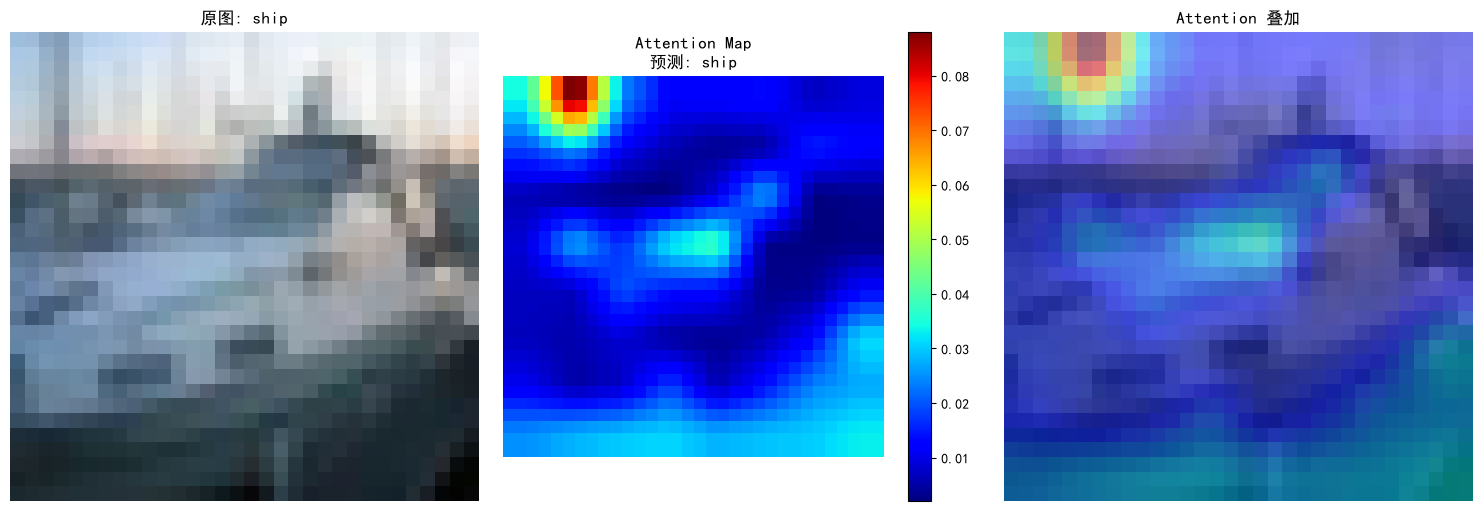

In [14]:
def visualize_attention(model, image, label, class_names, device):
    """
    可视化 ViT 对单张图片的 attention。
    
    参数:
        model: ViT 模型
        image: Tensor, shape (C, H, W)
        label: int, 真实标签
        class_names: 类别名列表
        device: 设备
    """
    model.eval()
    img = image.unsqueeze(0).to(device)  # (1, C, H, W)
    
    with torch.no_grad():
        logits, all_attns = model(img)
        pred = logits.argmax(dim=1).item()
    
    # 取最后一层的 attention: (batch, num_tokens, num_tokens)
    last_attn = all_attns[-1][0]  # (num_tokens, num_tokens)

    # CLS token 对所有 patch 的 attention（去掉 CLS 自己）
    cls_attn = last_attn[0, 1:].cpu().numpy()  # (num_patches,)
    
    # 计算 patch grid 大小
    num_patches = cls_attn.shape[0]
    grid_size = int(np.sqrt(num_patches))
    cls_attn_map = cls_attn.reshape(grid_size, grid_size)
    
    # 上采样到原图大小
    from PIL import Image
    attn_resized = Image.fromarray(cls_attn_map).resize((image.size(2), image.size(1)), Image.BILINEAR)
    attn_resized = np.array(attn_resized)
    
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 原图
    img_np = image.permute(1, 2, 0).cpu().numpy()
    # 反归一化（用于显示）
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    axes[0].imshow(img_np)
    axes[0].set_title(f"原图: {class_names[label]}")
    axes[0].axis('off')
    
    # Attention map
    im = axes[1].imshow(attn_resized, cmap='jet')
    axes[1].set_title(f"Attention Map\n预测: {class_names[pred]}")
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])
    
    # 叠加
    axes[2].imshow(img_np)
    axes[2].imshow(attn_resized, cmap='jet', alpha=0.5)
    axes[2].set_title("Attention 叠加")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


# 从测试集中选几张图片可视化
class_names = test_dataset.classes
for i in range(3):
    img, label = test_dataset[i]
    visualize_attention(small_vit, img, label, class_names, device)


> **观察**：
> 1. Attention map 是否集中在物体区域？
> 2. 不同 head 是否关注不同部位？
> 3. 从头训练的 ViT attention 可能不如预训练模型清晰，因为数据量小。
>
> 延伸：如果想看更精细的 attention，可以计算 "attention rollout"（Samira Abnar & Willem Zuidema, 2020），它考虑多层 attention 的累积效果。

## 11. 小结与延伸

本节课我们实现了 Vision Transformer，并在 CIFAR-10 上做了实验：

| 内容 | 关键点 |
|------|--------|
| Patch Embedding | 用 Conv2d 把图像切成 patch 并投影为 token |
| CLS Token | 可学习的分类 token，聚合全局信息 |
| Position Embedding | 可学习的 1D 位置编码 |
| ViT Block | Pre-LN + Multi-Head Attention + GELU MLP |
| 从头训练 | 小数据上 ViT 效果不如 ResNet |
| 预训练 Fine-tune | 大数据预训练让 ViT 非常强大 |
| Attention 可视化 | CLS-to-patch attention 展示模型关注区域 |

### 论文核心结论回顾

> Dosovitskiy et al. (2021): "We find that large scale training trumps inductive bias."

即：**当训练数据足够大时，Transformer 可以超越 CNN；数据量不足时，CNN 的归纳偏置更有优势。**

### 后续方向

1. **DeiT**：用知识蒸馏让小 ViT 在 ImageNet 上也能训练好。
2. **Swin Transformer**：引入层次化结构和局部窗口 attention，结合 CNN 和 ViT 优点。
3. **DETR / RT-DETR**：把 Transformer 用于目标检测。
4. **SegFormer**：把 Transformer 用于语义分割。
5. **SAM / DINO**：基于 ViT 的视觉基础模型。

下节课我们将进入目标检测，学习 YOLO 系列和 DETR。

## 参考

1. Dosovitskiy, A., et al. "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." *ICLR* 2021.
2. Vaswani, A., et al. "Attention Is All You Need." *NeurIPS* 2017.
3. Touvron, H., et al. "Training data-efficient image transformers \& distillation through attention." *ICML* 2021 (DeiT).
4. Liu, Z., et al. "Swin Transformer: Hierarchical Vision Transformer using Shifted Windows." *ICCV* 2021.